In [1]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
import torch.nn.functional as F
import pandas as pd
# 【重点】导入你现在训练好的模型类
from models.test_models import PureSAGEModel, PureDynamicGATModel, PureGCNModel, PureClassicGATModel
from models.hybrid_parallel_model import ParallelHybridStressModel 

In [21]:
# ----------------------------
# 推理函数 (Inference)
# ----------------------------
def inference(batch, model, device):
    """
    对单个图数据 batch 进行推理
    输入:
        batch: PyG 的 Data 对象
        model: 已加载权重的模型
        device: 当前设备 ('cuda' 或 'cpu')
    输出:
        singularity_probs: [N] 奇异点概率 (n_out[:, 0])
        online_probs: [N] 节点在线概率 (n_out[:, 1])
        edge_probs: [E] 边预测概率
    """
    model.eval()  # 确保处于评估模式，关闭 Dropout 等
    batch = batch.to(device)
    
    with torch.no_grad():
        # 模型输出的是原始 Logits (因为模型去掉了 Sigmoid 层)
        n_out, e_out = model(batch)
        
        # 1. 奇异点预测概率 (对应 n1_singularity)
        # 逻辑：sigmoid(Logit) -> 概率
        singularity_probs = torch.sigmoid(n_out).cpu().numpy()
        
        # 2. 节点在线概率预测 (对应 n2_online)
        #online_probs = torch.sigmoid(n_out[:, 1]).cpu().numpy()
        
        # 3. 边概率预测 (对应 e3_psl)
        # 注意：这里假设 edge_out 是 [N_edges, 1] 或 [N_edges]
        edge_probs = torch.sigmoid(e_out).view(-1).cpu().numpy()
        
    return singularity_probs, edge_probs

# ----------------------------
# 使用示例 (如何在评估时调用)
# ----------------------------
# sing_p, onl_p, edge_p = inference(test_graph, model, device)
# print(f"当前图节点数量: {len(sing_p)}")
# print(f"奇异点概率示例: {sing_p[:5]}")

In [22]:
sing_p, onl_p, edge_p = inference(test_graph, model, device)
print(f"当前图节点数量: {len(sing_p)}")
print(f"奇异点概率示例: {sing_p[:5]}")

NameError: name 'test_graph' is not defined

In [16]:

# 1. 简洁路径 (请替换为你存放 best_model.pth 的真实路径)
model_path = r"D:\2025-2026 RA\3-sitp 2026 基于图学习的楼板应力线找形\composite\trained_model\2026_06_02\ParallelHybridStressModel\best_model.pth" 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. 实例化模型
# 【关键】：这里一定要加上 head=8，且参数要与你训练时保存模型时的一模一样
# 如果你训练时改过 hidden_dim1/2，这里也要同步修改
model = ParallelHybridStressModel(
    input_dim=13, 
    hidden_dim1=128, 
    hidden_dim2=64, 
    head=8
).to(device)

print("Loading trained model...")

# 加载状态字典
state_dict = torch.load(model_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()
print("Model loaded.")


Loading trained model...
Model loaded.


# 评估方法一：读取数据集作为模型输入

In [26]:
# =========================================================================
# Cell 4: 批量评估与指标计算 (支持多任务与连续概率保留)
# =========================================================================
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score

# 1. 设置二值化评估的阈值 (仅用于评估，可视化时不改变原始概率)
THRESHOLDS = {"singularity": 0.8, "online": 0.5, "edge": 0.5}

# 2. 加载数据集
data_path = r'D:\2025-2026 RA\3-sitp 2026 基于图学习的楼板应力线找形\composite\graph_dataset\20260601_106cases.pt'
dataset = torch.load(data_path, weights_only=False)
test_loader = DataLoader(dataset, batch_size=1, shuffle=False)

# 3. 初始化存储容器 (用于存放全量概率预测和真实标签)
all_results = {
    "sing": {"p": [], "l": []},
    "onl":  {"p": [], "l": []},
    "edge": {"p": [], "l": []}
}

print("🚀 开始批量推理...")

# 4. 循环遍历所有图数据进行推理
for batch in test_loader:
    # 调用Cell 2的推理函数，得到 [N] 或 [E] 维度的概率数组
    sing_p, edge_p = inference(batch, model, device)
    onl_p  = sing_p
    # 5. 提取真实标签 (Raw Labels: 原始连续值)
    # y_node[:, 0]为奇异点, y_node[:, 1]为在线任务, y_edge为边任务
    sing_l = batch.y_node[:, 0].cpu().numpy()
    onl_l  = sing_l
    edge_l = batch.y_edge.cpu().numpy()
    
    # 6. 将结果存入容器
    all_results["sing"]["p"].append(sing_p); all_results["sing"]["l"].append(sing_l)
    all_results["onl"]["p"].append(onl_p);   all_results["onl"]["l"].append(onl_l)
    all_results["edge"]["p"].append(edge_p); all_results["edge"]["l"].append(edge_l)

 
# 7. 辅助函数：计算并打印评估指标
def evaluate_and_print(name, key, threshold):
    # 合并成长数组
    probs = np.concatenate(all_results[key]["p"])
    raw_labels = np.concatenate(all_results[key]["l"])
    
    # --- 【修改这里】：将连续的 raw_labels 强制二值化 ---
    # 只有二值化后，roc_auc_score 才能识别这依然是分类问题
    labels_bin = (raw_labels >= threshold).astype(int)
    
    # 二值化处理 (仅评估使用)
    preds_bin  = (probs >= threshold).astype(int)
    
    # 【关键修改】：roc_auc_score 的第一个参数使用 labels_bin (二值化后的)
    auc = roc_auc_score(labels_bin, probs) 
    
    # 计算 ACC 和 F1
    acc = accuracy_score(labels_bin, preds_bin)
    f1  = f1_score(labels_bin, preds_bin, zero_division=0)
    
    print(f"--- {name} 评估结果 ---")
    print(f"AUC: {auc:.4f} | ACC: {acc:.4f} | F1: {f1:.4f}")

# 8. 执行三个维度的评估
evaluate_and_print("节点奇异点预测", "sing", THRESHOLDS["singularity"])
evaluate_and_print("节点在线预测",   "onl",  THRESHOLDS["online"])
evaluate_and_print("边主应力线预测", "edge", THRESHOLDS["edge"])

# 【提示】：all_results["xxx"]["p"] 中保存的是完整的概率值，可视化时直接调用即可！

🚀 开始批量推理...
--- 节点奇异点预测 评估结果 ---
AUC: 0.6327 | ACC: 0.9999 | F1: 0.0000
--- 节点在线预测 评估结果 ---
AUC: 0.6167 | ACC: 0.0002 | F1: 0.0003
--- 边主应力线预测 评估结果 ---
AUC: 0.5108 | ACC: 0.0057 | F1: 0.0113


In [27]:
sing_p

array([[0.60007817],
       [0.60110754],
       [0.60099626],
       ...,
       [0.59654456],
       [0.59668195],
       [0.60078144]], shape=(11371, 1), dtype=float32)

In [28]:
sing_l

array([0.77935255, 0.64578724, 0.2455107 , ..., 0.        , 0.        ,
       0.        ], shape=(11371,), dtype=float32)

# 评估方法二：从表格读取数据作为模型输入

In [17]:
# --- Cell 5: 导入核心函数 ---
# 既然原文件里定义的是 read_stress_graph，我们就导入它
from utils.read_oridata import read_stress_graph

In [29]:
# --- Cell 6: 读取并构造图 ---
node_path = r"D:\2025-2026 RA\3-sitp 2026 基于图学习的楼板应力线找形\composite\initial_dataset\1.1 nodes.csv"
edge_path = r"D:\2025-2026 RA\3-sitp 2026 基于图学习的楼板应力线找形\composite\initial_dataset\1.1 edges.csv"


# 确保运行过这几行！
df_nodes = pd.read_csv(node_path)
df_edges = pd.read_csv(edge_path)

# 直接调用你定义的这个强大函数，它会返回一个标准的 Data 对象
graph = read_stress_graph(node_path, edge_path)

# 将图移到 GPU 上
graph = graph.to(device)

print(f"✅ 图构建完成！节点特征形状: {graph.x.shape}, 边索引形状: {graph.edge_index.shape}")

✅ 图构建完成！节点特征形状: torch.Size([11371, 13]), 边索引形状: torch.Size([2, 33714])


In [30]:
# ----------------------------
# Cell 7: 单图推理 (最终修复版)
# ----------------------------
model.eval()
with torch.no_grad():
    # 直接对单张图进行推理
    #sing_p, onl_p, edge_p = inference(graph, model, device)
    sing_p, edge_p = inference(graph, model, device)

# --- 关键修改：直接赋值，不需要再调用 .cpu().numpy() ---
# 如果 sing_p 本身已经是 numpy 数组，直接这样写：
df_nodes['singularity'] = sing_p 
#df_nodes['on_psl']      = onl_p

# 边表也是一样，直接赋值
df_edges['close_to_psl'] = edge_p[:len(df_edges)]

print(f"✅ 推理成功！节点数: {len(df_nodes)}, 边数: {len(df_edges)}")

✅ 推理成功！节点数: 11371, 边数: 33714


# 可视化

- **jupyter lab 的可视化需要安装两个库，运行以下两行代码进行安装**
- `conda install nodejs`
- `pip install "jupyterlab>=3.0.0,<5.0.0" plotly`

- **运行下面这行代码安装扩展**
- `jupyter labextension install jupyterlab-plotly`

In [33]:
# --- 必须先确保绘图函数存在 ---
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
import numpy as np

def plot_triple_analysis(col_node1, col_node2, col_edge):
    """
    绘制三张对比图：节点特征1、节点特征2、边特征对齐图
    """
    fig, axes = plt.subplots(1, 3, figsize=(22, 6))
    x, y = df_nodes['x'], df_nodes['y']

    # 图1
    prob1 = df_nodes[col_node1]
    sc1 = axes[0].scatter(x, y, c=prob1, cmap='Reds', s=15, alpha=0.7)
    fig.colorbar(sc1, ax=axes[0], label='Probability')
    axes[0].set_title(col_node1)
    
    # 图2
    prob2 = df_nodes[col_node2]
    sc2 = axes[1].scatter(x, y, c=prob2, cmap='Blues', s=15, alpha=0.7)
    fig.colorbar(sc2, ax=axes[1], label='Probability')
    axes[1].set_title(col_node2)

    # 图3
    node_coords = df_nodes.set_index('node_id')[['x', 'y']].to_dict('index')
    lines, edge_weights = [], []
    for _, row in df_edges.iterrows():
        u, v = int(row['start_id']), int(row['end_id'])
        if u in node_coords and v in node_coords:
            lines.append([(node_coords[u]['x'], node_coords[u]['y']), 
                          (node_coords[v]['x'], node_coords[v]['y'])])
            edge_weights.append(row[col_edge])
    
    lc = LineCollection(lines, array=np.array(edge_weights), cmap='Greens', norm=Normalize(0, 1))
    axes[2].add_collection(lc)
    axes[2].set_xlim(x.min(), x.max())
    axes[2].set_ylim(y.min(), y.max())
    axes[2].set_title('Edge: ' + col_edge)
    
    plt.tight_layout()
    plt.show() # 这行代码负责显示图像，不需要额外写 fig.show()

In [32]:
model.eval()
with torch.no_grad():
    # 注意：根据你之前定义的 inference 函数，可能需要 graph 或 graph.unsqueeze(0)
    # 请确保这里的变量名与你的 model 定义一致
    sing_p, onl_p, edge_p = inference(graph, model, device) 

# 这里不需要加任何其他代码，推理出的这三个变量会自动进入内存供 Cell 8 调用
print("✅ 模型推理完成，概率张量已生成。")

ValueError: not enough values to unpack (expected 3, got 2)

In [10]:
sing_p

NameError: name 'sing_p' is not defined

🎨 正在绘制模型预测结果...


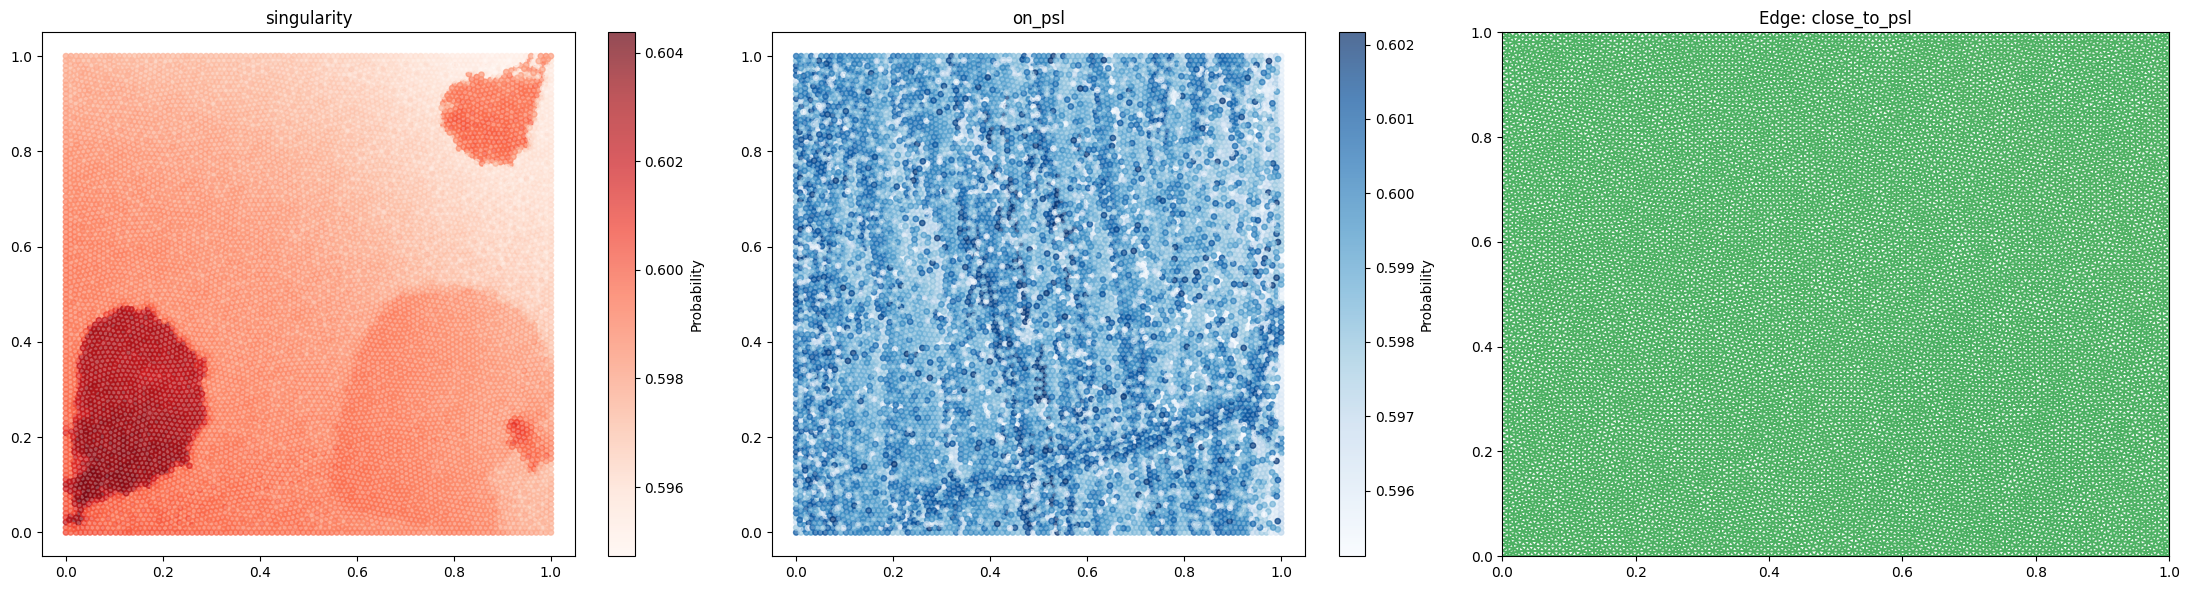

✅ 模型预测结果绘图完成！


In [34]:
# ----------------------------
# Cell 8: 可视化模型预测的应力场与应力线 (最终修正版)
# ----------------------------

# 1. 确保你刚刚运行过 Cell 7 里的推理，并且拿到了单图的预测结果：
# sing_p, onl_p, edge_p (请确认这三个变量在内存中已存在)

# 2. 直接在原始数据框上创建预测列 (直接覆盖，不需要 copy 也不需要 all_ 列表)
df_nodes['singularity'] = sing_p.flatten() if hasattr(sing_p, 'flatten') else sing_p
df_nodes['on_psl']      = onl_p.flatten() if hasattr(onl_p, 'flatten') else onl_p
df_edges['close_to_psl'] = edge_p.flatten()[:len(df_edges)]

# 3. 直接调用绘图函数
print("🎨 正在绘制模型预测结果...")
plot_triple_analysis('singularity', 'on_psl', 'close_to_psl')

print("✅ 模型预测结果绘图完成！")

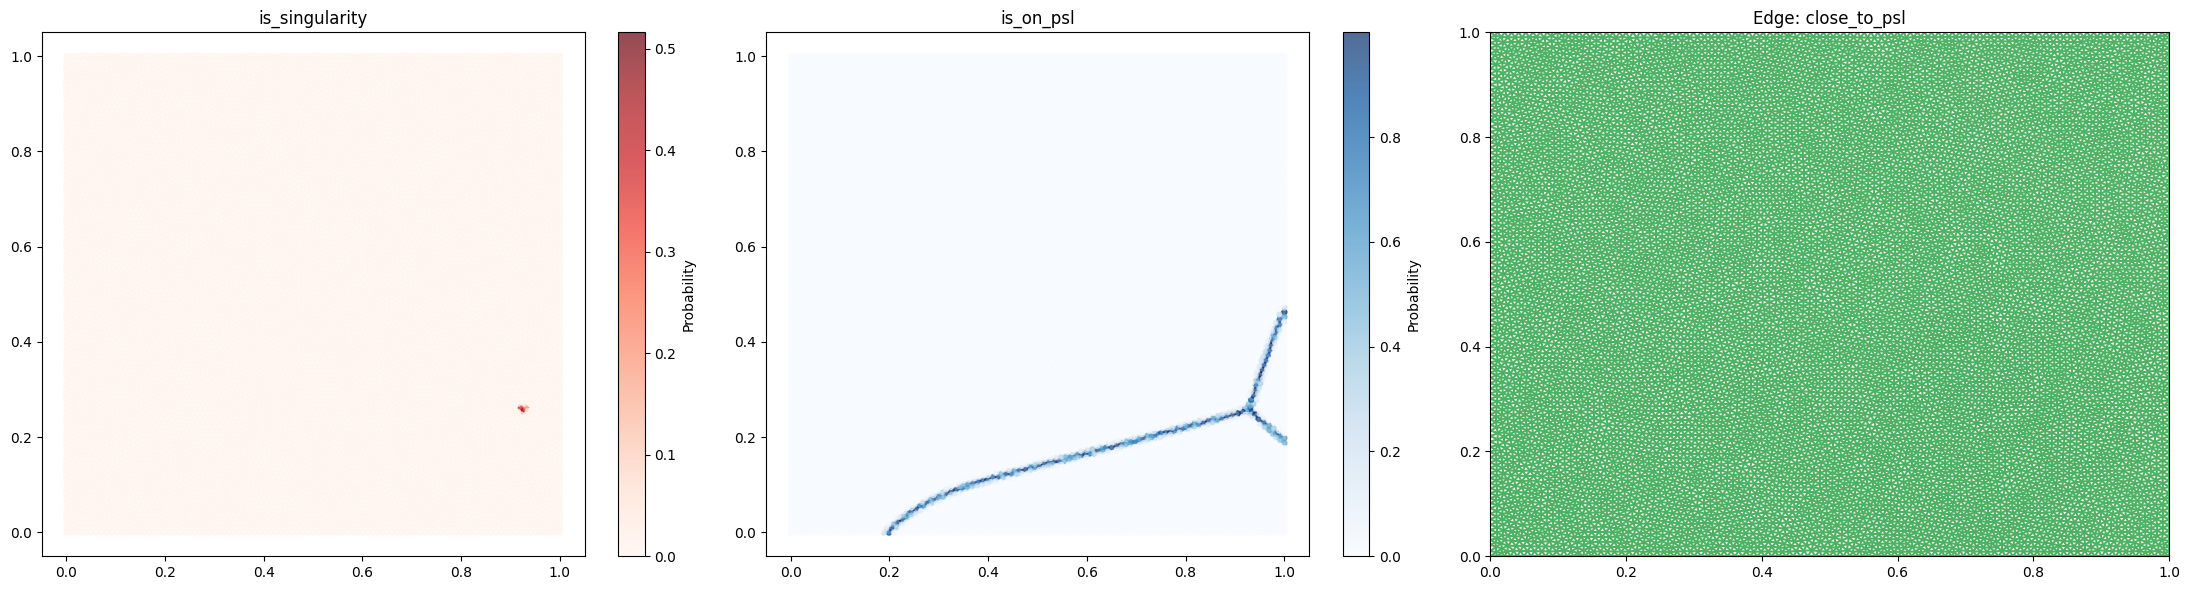

In [35]:
plot_triple_analysis('is_singularity', 'is_on_psl', 'close_to_psl')

In [36]:
sing_p

array([[0.5977904 ],
       [0.5986569 ],
       [0.5978957 ],
       ...,
       [0.59653324],
       [0.5965815 ],
       [0.60262585]], shape=(11371, 1), dtype=float32)

In [37]:
onl_p

array([[0.60007817],
       [0.60110754],
       [0.60099626],
       ...,
       [0.59654456],
       [0.59668195],
       [0.60078144]], shape=(11371, 1), dtype=float32)